In [9]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel , Field

from langchain_core.messages import SystemMessage
from langchain_groq import ChatGroq
from langchain_core.runnables import RunnableConfig

from langgraph.graph import START , END , StateGraph , MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [2]:
store=InMemoryStore()

In [3]:
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible.

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""

In [4]:
memory_llm=ChatGroq(model='openai/gpt-oss-120b')

In [5]:
class MemoryItem(BaseModel):
    text :str =Field(description='Atomic user memory')
    is_new :bool=Field(description='True if the following memory is new  , false if it already exist')
 

In [16]:
class MemoryDecision(BaseModel):
    should_write:bool =Field(description='Whether to store any memories ?')
    memories :List[MemoryItem] =Field(description='Atomic user memory to store')

In [17]:
memory_extractor=memory_llm.with_structured_output(MemoryDecision)

In [18]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return should_write=false and an empty list.
"""

In [19]:
def remember_node(state : MessagesState ,config :RunnableConfig ,store :BaseStore ):
    user_id=config['configurable']['user_id']

    namespace=('user',user_id,'details')

    items=store.search(namespace)

    existing = "\n".join(it.value["data"] for it in items) if items else "(empty)"

    # last user message
    last_msg = state["messages"][-1].content

    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=existing)),
            {"role": "user", "content": last_msg},
        ]
    )

    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(namespace, str(uuid.uuid4()), {"data": mem.text})

    return {}

In [20]:
chat_llm=ChatGroq(model='openai/gpt-oss-120b')

In [21]:
def chat_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    ns = ("user", user_id, "details")

    items = store.search(ns)
    user_details = "\n".join(it.value["data"] for it in items) if items else ""

    system_msg = SystemMessage(
        content=SYSTEM_PROMPT_TEMPLATE.format(
            user_details_content=user_details or "(empty)"
        )
    )

    response = chat_llm.invoke([system_msg] + state["messages"])
    return {"messages": [response]}

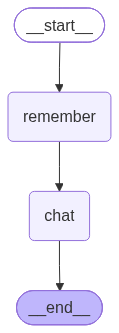

In [22]:
builder = StateGraph(MessagesState)
builder.add_node("remember", remember_node)
builder.add_node("chat", chat_node)

builder.add_edge(START, "remember")
builder.add_edge("remember", "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [23]:
config = {"configurable": {"user_id": "u1"}}

In [24]:
result = graph.invoke({"messages": [{"role": "user", "content": "Hi, my name is Kabir "}]}, config)
result['messages'][-1].content

'Hey Kabir! 👋 Great to meet you. How can I help you today?  \n\n**Here are a few things you might want to explore next:**\n\n1. **What kind of project are you working on right now?** (e.g., web development, data analysis, automation)  \n2. **Do you need help with a specific programming language or tool?** (Python, JavaScript, Docker, etc.)  \n3. **Are you looking for resources or tutorials on a particular topic?** (machine learning, cloud deployment, UI/UX design)\n\nFeel free to pick any of those or let me know something else you’re curious about!'

In [25]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

The user’s name is Kabir.


In [26]:
result = graph.invoke({"messages": [{"role": "user", "content": "I am student pursuing BTech in CSE "}]}, config)
print(result['messages'][-1].content)

Hey Kabir! 🎓  

It’s great to hear you’re pursuing a BTech in Computer Science and Engineering. Whether you’re tackling data structures, diving into algorithms, working on a cool project, or thinking about internships, I’m here to help.

What are you working on right now, or is there a particular topic you’d like some guidance on? Feel free to let me know—whether it’s study strategies, coding help, project ideas, or anything else related to your CSE journey.  

---

**Here are three follow‑up questions you might find useful:**

1. Are there any specific subjects or concepts in your CSE curriculum that you’d like clarified or extra practice with?  
2. Do you have a personal or academic project in mind that you’d like help planning or debugging?  
3. Are you exploring internship or job opportunities, and would you like tips on building a strong resume or preparing for technical interviews?  


In [27]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

The user’s name is Kabir.
The user is a BTech student in Computer Science and Engineering.


In [28]:
result = graph.invoke({"messages": [{"role": "user", "content": "Explain GenAI simply"}]}, config)
print(result['messages'][-1].content)

Sure, Kabir—let’s break down Generative AI (Gen AI) in a way that clicks with a BTech CS student.

---

## 1. What “generative” means
- **Generative** = *creates something new* (text, images, music, code, etc.) rather than just classifying or retrieving existing data.
- Think of it as a **smart composer** that learns patterns from a huge dataset and then writes its own “songs” that follow those patterns.

## 2. Core idea in a nutshell
1. **Training phase** – A neural network (usually a **Transformer**) is fed massive amounts of data (e.g., books, code repositories, images).  
2. **Learning phase** – The model learns statistical relationships: “If I see this context, the next word/pixel/command is likely X.”  
3. **Generation phase** – Given a prompt, the model samples from those learned probabilities to produce a fresh output.

## 3. How it actually works (high‑level)
| Step | What happens | Analogy |
|------|--------------|---------|
| **Input (prompt)** | You give a short instruction

In [29]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

The user’s name is Kabir.
The user is a BTech student in Computer Science and Engineering.
